#1. Анализ двухмерного массива NumPy

Задача: Дан двумерный массив чисел. Необходимо найти сумму всех четных чисел в каждом ряду (строке), затем вывести ряд с максимальной суммой четных значений.


## Примечание

Исходя из текста задачи создаётся впечетление, что просуммировать нужно ЧЁТНЫЕ ЧИСЛА. Но исходя из примера решения становится понятно, что нужно просуммировать ЧЁТНЫЕ СТОЛБЦЫ.

На всякий случай я предоставил 2 варианта решения, для каждого из возможных значений задания.

In [6]:
import numpy as np

np.random.seed(42)
matrix = np.random.randint(1, 100, size=(5, 5))

# Создаём булеву маску для чётных чисел и обнуляем нечётные
even_sums = (matrix * (matrix % 2 == 0)).sum(axis=1)

max_row_idx = np.argmax(even_sums)

print(f'\nМатрица:\n{matrix}')
print(f'\nСуммы чётных чисел по строкам: {even_sums}')
print(f'\nСтрока с максимальной суммой чётных чисел: {max_row_idx} (сумма: {even_sums[max_row_idx]})')



Матрица:
[[52 93 15 72 61]
 [21 83 87 75 75]
 [88 24  3 22 53]
 [ 2 88 30 38  2]
 [64 60 21 33 76]]

Суммы чётных чисел по строкам: [124   0 134 160 200]

Строка с максимальной суммой чётных чисел: 4 (сумма: 200)


In [5]:
import numpy as np

np.random.seed(42)
matrix = np.random.randint(1, 100, size=(5, 5))

# Суммируем элементы чётных колонок по каждой строке
even_col_sums = np.array([matrix[i, ::2].sum() for i in range(matrix.shape[0])])

max_row_idx = np.argmax(even_col_sums)

print(f'\nМатрица:\n{matrix}')
print(f'\nСуммы элементов чётных колонок по строкам: {even_col_sums}')
print(f'\nСтрока с максимальной суммой: {max_row_idx} (сумма: {even_col_sums[max_row_idx]})')


Матрица:
[[52 93 15 72 61]
 [21 83 87 75 75]
 [88 24  3 22 53]
 [ 2 88 30 38  2]
 [64 60 21 33 76]]

Суммы элементов чётных колонок по строкам: [128 183 144  34 161]

Строка с максимальной суммой: 1 (сумма: 183)


------------------------------------------------------

#2. Обработка отсутствующих данных в DataFrame (Pandas)

Задача: Дана таблица с пропущенными значениями (NaN), заполните пропуски средним значением соответствующего столбца.

In [8]:
import pandas as pd
import numpy as np

data = {
    'A': [1, 2, np.nan],
    'B': [np.nan, 4, 5],
    'C': [6, 7, 8]
}

df = pd.DataFrame(data)

# Заполняем пропуски средним значением каждого столбца по отдельности
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].mean())

print(df)


     A    B  C
0  1.0  4.5  6
1  2.0  4.0  7
2  1.5  5.0  8


---------------------------------------------------------------

#3. Группировка и агрегация данных (Pandas)

Задача: Есть список покупок разных клиентов с разными товарами и ценами. Найдите среднюю цену каждого товара по категориям товаров.

In [9]:
import pandas as pd

data = {
    'customer_id': ['Alice', 'Bob', 'Charlie', 'Alice'],
    'product_category': ['Electronics', 'Clothing', 'Books', 'Electronics'],
    'price': [100, 50, 20, 150]
}

df = pd.DataFrame(data)

# Вычисляем среднюю цену по каждой категории и сортируем по убыванию
avg_prices = df.groupby('product_category')['price'].mean().sort_values(ascending=False)

print('Средняя цена товаров по категориям:')
for category, avg in avg_prices.items():
    print(f'  {category}: {avg:.2f}')


Средняя цена товаров по категориям:
  Electronics: 125.00
  Clothing: 50.00
  Books: 20.00


-------------------------------------------------------------------

#4. Математические операции над многомерными массивами (NumPy)

Задача: Реализовать свертку (convolution) одномерного сигнала с ядром (kernel).

Дан сигнал длиной N и ядро K длины M (например, фильтр Гаусса):

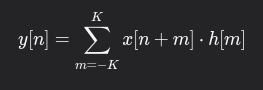

где x — входной сигнал, h — ядро фильтра, y — выходная последовательность.

Реализуйте операцию вручную без встроенных функций вроде convolve() или аналогичных методов.

In [11]:
import numpy as np

def my_convolution(signal, kernel):
    n = len(signal)
    m = len(kernel)
    result = np.zeros(n + m - 1)

    # Для каждого коэффициента ядра сдвигаем сигнал и накапливаем вклад
    for k, coef in enumerate(kernel):
        result[k:k + n] += signal * coef

    return result

signal = np.array([1, 2, 3, 4, 5])
kernel = np.array([0.25, 0.5, 0.25])  # пример ядра

output = my_convolution(signal, kernel)
print(output)


[0.25 1.   2.   3.   4.   3.5  1.25]


---------------------------------------

#5. Запись результата анализа в файл

Задача: Построить гистограмму распределения возрастов пользователей из файла и сохранить её в виде графика в PNG файле.

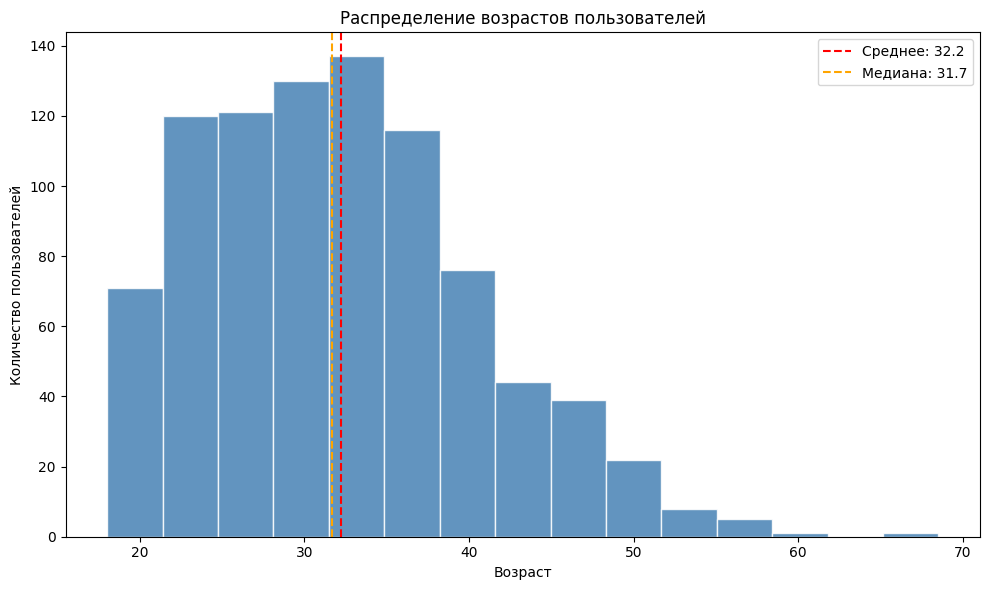

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных возраста
np.random.seed(42)  # Зафиксируем seed для воспроизводимости результатов
n_users = 1000       # Количество пользователей
mean_age = 30        # Среднее значение возраста
std_dev = 10         # Стандартное отклонение

# Генерируем нормально распределённые данные с заданными параметрами
ages = np.random.normal(mean_age, std_dev, n_users)

# Ограничиваем диапазон возрастов от 18 до 70 лет
ages = ages[(ages >= 18) & (ages <= 70)]

# Преобразуем массив возрастов в DataFrame
data = pd.DataFrame({'age': ages})

mean_val = data['age'].mean()
median_val = data['age'].median()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data['age'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)

# Отмечаем среднее и медиану вертикальными линиями
ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {mean_val:.1f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=1.5, label=f'Медиана: {median_val:.1f}')

ax.set_title('Распределение возрастов пользователей')
ax.set_xlabel('Возраст')
ax.set_ylabel('Количество пользователей')
ax.legend()
plt.tight_layout()
plt.savefig('histogram.png')
plt.show()
